In [7]:
# =============================================================================
# 全局参数区
# =============================================================================

DATA_ROOT = r"C:\Desktop\讲座课件\THUCNews_selected"

CATEGORIES = ["家居", "星座", "时尚", "体育", "财经"]

N_TOPICS = 5
N_TOP_WORDS = 20
MAX_FEATURES = 1000
MIN_DF = 5
MAX_DOCS_PER_CATEGORY = 100

OUTPUT_DIR = r"C:\temp\lda_thucnews"

CUSTOM_STOPWORDS = {
    "我们", "你们", "他们", "自己", "这个", "那个",
    "这些", "那些", "一个", "一种", "一些",
    "以及", "因为", "所以", "但是", "如果",
    "目前", "已经", "可以", "进行", "没有",
    "表示", "认为", "记者", "报道", "消息",
    "问题", "情况", "方面", "时候", "内容"
}

In [8]:
# -----------------------------------------------------------------------------
# Step 2：读取THUCNews文本
# -----------------------------------------------------------------------------

from pathlib import Path
import os
import pandas as pd

os.makedirs(OUTPUT_DIR, exist_ok=True)

documents = []
actual_labels = []
file_names = []

for category in CATEGORIES:

    category_dir = Path(DATA_ROOT) / category

    # 同时识别 .txt、.TXT 等扩展名，且不会重复读取
    file_list = sorted([
        file_path
        for file_path in category_dir.iterdir()
        if file_path.is_file()
        and file_path.suffix.lower() == ".txt"
    ])

    # 每个类别最多读取指定数量
    file_list = file_list[:MAX_DOCS_PER_CATEGORY]

    print(f"{category}：读取 {len(file_list)} 篇")

    for file_path in file_list:

        try:
            text = file_path.read_text(
                encoding="utf-8"
            ).strip()

        except UnicodeDecodeError:
            text = file_path.read_text(
                encoding="gb18030",
                errors="ignore"
            ).strip()

        if text:
            documents.append(text)
            actual_labels.append(category)
            file_names.append(file_path.name)

df_documents = pd.DataFrame({
    "文件名": file_names,
    "实际类别": actual_labels,
    "文本": documents
})

print("-" * 40)
print("实际读取文档总数：", len(df_documents))

display(
    df_documents["实际类别"]
    .value_counts()
    .reindex(CATEGORIES)
    .rename("文档数")
    .to_frame()
)

家居：读取 100 篇
星座：读取 100 篇
时尚：读取 100 篇
体育：读取 100 篇
财经：读取 100 篇
----------------------------------------
实际读取文档总数： 500


,文档数
实际类别,
家居,100
星座,100
时尚,100
体育,100
财经,100


In [9]:
# -----------------------------------------------------------------------------
# Step 3：中文分词，只保留名词
# -----------------------------------------------------------------------------

import jieba.posseg as pseg


def noun_tokenizer(text):
    """
    使用jieba进行词性标注，只保留名词。

    jieba名词类词性包括：
    n  ：普通名词
    nr ：人名
    ns ：地名
    nt ：机构名
    nz ：其他专有名词
    """

    nouns = []

    for word, flag in pseg.cut(str(text)):

        word = word.strip()

        if (
            flag.startswith("n")
            and len(word) >= 2
            and word not in CUSTOM_STOPWORDS
            and not word.isdigit()
        ):
            nouns.append(word)

    return nouns


# 查看第一篇文档提取出的前30个名词
print(noun_tokenizer(documents[0])[:30])

C:\AppData\Local\Programs\Python\Python312\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache C:\AppData\Local\Temp\jieba.cache
Loading model cost 0.630 seconds.
Prefix dict has been built successfully.


['昆明', '慕思', '慕思', '欧洲', '文化', '春城', '新浪', '乐居', '编辑', '李秀婷', '昆明', '慕思', '慕思', '欧洲', '文化', '昆明', '世纪', '金源', '隆重举行', '昆明', '慕思', '慕思', '全球', '资源', '全面', '昆明', '春城', '人民', '优质', '体验']


In [10]:
# -----------------------------------------------------------------------------
# Step 4：构建TF词频矩阵
# LDA使用CountVectorizer，而不是TfidfVectorizer
# -----------------------------------------------------------------------------

from sklearn.feature_extraction.text import CountVectorizer

print("正在建立TF词频矩阵……")

vectorizer = CountVectorizer(
    tokenizer=noun_tokenizer,
    token_pattern=None,
    min_df=MIN_DF,
    max_df=0.90,
    max_features=MAX_FEATURES
)

X_tf = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()

print("TF矩阵形状：", X_tf.shape)
print("文档数：", X_tf.shape[0])
print("特征词数：", X_tf.shape[1])
print("矩阵中的总词频：", X_tf.sum())

正在建立TF词频矩阵……
TF矩阵形状： (500, 1000)
文档数： 500
特征词数： 1000
矩阵中的总词频： 68299


In [11]:
#%pip uninstall -y gensim numpy scipy
#%pip install --no-cache-dir numpy==1.26.4 scipy==1.12.0 gensim==4.3.3

正在自动选择Topic数……
Topic数 =  2，测试集Perplexity = 710.39
Topic数 =  3，测试集Perplexity = 611.91
Topic数 =  4，测试集Perplexity = 584.78
Topic数 =  5，测试集Perplexity = 575.23
Topic数 =  6，测试集Perplexity = 624.31
Topic数 =  7，测试集Perplexity = 617.32
Topic数 =  8，测试集Perplexity = 625.97
Topic数 =  9，测试集Perplexity = 636.75
Topic数 = 10，测试集Perplexity = 661.98
Topic数 = 11，测试集Perplexity = 686.17
Topic数 = 12，测试集Perplexity = 713.23
Topic数 = 13，测试集Perplexity = 726.01
Topic数 = 14，测试集Perplexity = 755.37
Topic数 = 15，测试集Perplexity = 781.18
--------------------------------------------------
自动推荐Topic数：5
最低测试集Perplexity： 575.23


,Topic数,测试集Perplexity
0,2,710.39
1,3,611.91
2,4,584.78
3,5,575.23
4,6,624.31
5,7,617.32
6,8,625.97
7,9,636.75
8,10,661.98
9,11,686.17


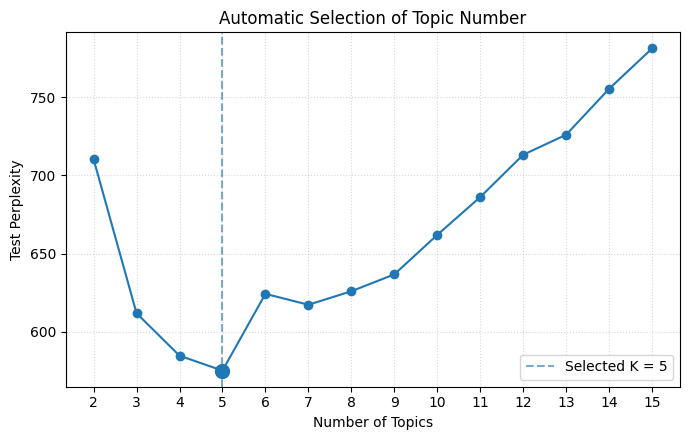


正在建立最终LDA模型：Topic数 = 5

LDA模型建立完成
最终Topic数： 5
文档—主题矩阵： (500, 5)
主题—词语矩阵： (5, 1000)
迭代次数： 30
全部数据Perplexity： 323.16


In [12]:
# -----------------------------------------------------------------------------
# Step 5：执行LDA主题分析
# - 支持手动指定Topic数
# - 支持自动选择Topic数（测试集Perplexity）
# - 使用单进程，避免Windows的BrokenProcessPool错误
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split


# =============================================================================
# 1. Topic数设置区
# =============================================================================

# "manual"：手动指定
# "auto"  ：自动选择
TOPIC_MODE = "auto"
#TOPIC_MODE = "manual"

# 手动模式使用
MANUAL_N_TOPICS = 4

# 自动模式的搜索范围
MIN_TOPICS = 2
MAX_TOPICS = 15

# LDA最大迭代次数
MAX_ITER = 30


# =============================================================================
# 2. 手动指定Topic数
# =============================================================================

if TOPIC_MODE == "manual":

    N_TOPICS = MANUAL_N_TOPICS

    print(f"手动指定Topic数：{N_TOPICS}")


# =============================================================================
# 3. 自动选择Topic数
# =============================================================================

elif TOPIC_MODE == "auto":

    print("正在自动选择Topic数……")

    # 将TF矩阵划分为训练集和测试集
    X_train, X_test = train_test_split(
        X_tf,
        test_size=0.20,
        random_state=42
    )

    topic_candidates = list(
        range(MIN_TOPICS, MAX_TOPICS + 1)
    )

    perplexity_results = []

    for k in topic_candidates:

        lda_temp = LatentDirichletAllocation(
            n_components=k,
            learning_method="batch",
            max_iter=MAX_ITER,
            random_state=42,

            # 重要：使用单进程，避免BrokenProcessPool
            n_jobs=1
        )

        # 在训练集上建模
        lda_temp.fit(X_train)

        # 在测试集上计算困惑度
        test_perplexity = lda_temp.perplexity(X_test)

        perplexity_results.append(test_perplexity)

        print(
            f"Topic数 = {k:2d}，"
            f"测试集Perplexity = {test_perplexity:.2f}"
        )

    # 困惑度最低的位置
    best_index = int(
        np.argmin(perplexity_results)
    )

    N_TOPICS = topic_candidates[best_index]

    print("-" * 50)
    print(f"自动推荐Topic数：{N_TOPICS}")
    print(
        "最低测试集Perplexity：",
        round(perplexity_results[best_index], 2)
    )


    # 结果表
    df_topic_selection = pd.DataFrame({
        "Topic数": topic_candidates,
        "测试集Perplexity": perplexity_results
    })

    display(
        df_topic_selection.round(2)
    )


    # 绘制困惑度曲线
    plt.figure(figsize=(7, 4.5))

    plt.plot(
        topic_candidates,
        perplexity_results,
        marker="o"
    )

    plt.scatter(
        N_TOPICS,
        perplexity_results[best_index],
        s=100,
        zorder=3
    )

    plt.axvline(
        N_TOPICS,
        linestyle="--",
        alpha=0.6,
        label=f"Selected K = {N_TOPICS}"
    )

    plt.xlabel("Number of Topics")
    plt.ylabel("Test Perplexity")
    plt.title("Automatic Selection of Topic Number")
    plt.xticks(topic_candidates)
    plt.legend()
    plt.grid(
        linestyle=":",
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()


else:

    raise ValueError(
        'TOPIC_MODE只能设置为"manual"或"auto"'
    )


# =============================================================================
# 4. 使用选定的Topic数建立最终LDA模型
# =============================================================================

print(
    f"\n正在建立最终LDA模型："
    f"Topic数 = {N_TOPICS}"
)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    learning_method="batch",
    max_iter=MAX_ITER,
    random_state=42,

    # 同样使用单进程
    n_jobs=1
)

# 文档 × 主题概率矩阵
document_topic = lda.fit_transform(X_tf)

# 主题 × 词语权重矩阵
topic_word = lda.components_


# =============================================================================
# 5. 输出结果
# =============================================================================

print("\nLDA模型建立完成")
print("最终Topic数：", N_TOPICS)
print("文档—主题矩阵：", document_topic.shape)
print("主题—词语矩阵：", topic_word.shape)
print("迭代次数：", lda.n_iter_)
print(
    "全部数据Perplexity：",
    round(lda.perplexity(X_tf), 2)
)

In [13]:
# -----------------------------------------------------------------------------
# Step 6：显示各主题的关键词
# -----------------------------------------------------------------------------

import pandas as pd
from IPython.display import display, Markdown

topic_summaries = []

for topic_index, word_weights in enumerate(topic_word):

    top_indices = word_weights.argsort()[::-1][:N_TOP_WORDS]
    top_words = feature_names[top_indices]

    topic_summaries.append({
        "主题编号": f"主题 {topic_index + 1}",
        "主题关键词": "、".join(top_words)
    })

df_topics = pd.DataFrame(topic_summaries)

display(Markdown("### LDA提取的主题及核心关键词"))
display(df_topics)

topic_table_path = os.path.join(
    OUTPUT_DIR,
    "LDA主题关键词.csv"
)

df_topics.to_csv(
    topic_table_path,
    index=False,
    encoding="utf-8-sig"
)

print("关键词表保存位置：", topic_table_path)

### LDA提取的主题及核心关键词

,主题编号,主题关键词
0,主题 1,爱情、朋友、男人、女人、星座、对方、白羊、感情、事情、感觉、天蝎座、处女座、时间、天秤座、单...
1,主题 2,价格、期货、市场、身体、女性、食物、美国、经济、压力、现货、时间、中国、营养、米兰、黄金、早...
2,主题 3,球队、球员、约会、球迷、时间、机会、中国、主场、火箭、足球、冠军、俱乐部、吉时、本赛季、姚明...
3,主题 4,基金、公司、市场、机构、股票、账户、资金、华夏、业绩、投资者、产品、收益、经理、规模、证券、...
4,主题 5,企业、中国、产品、市场、行业、品牌、家具、家居、消费者、设计师、产业、北京、建材、全国、国际...


关键词表保存位置： C:\temp\lda_thucnews\LDA主题关键词.csv


当前主题数量： 5
使用中文字体： Microsoft YaHei


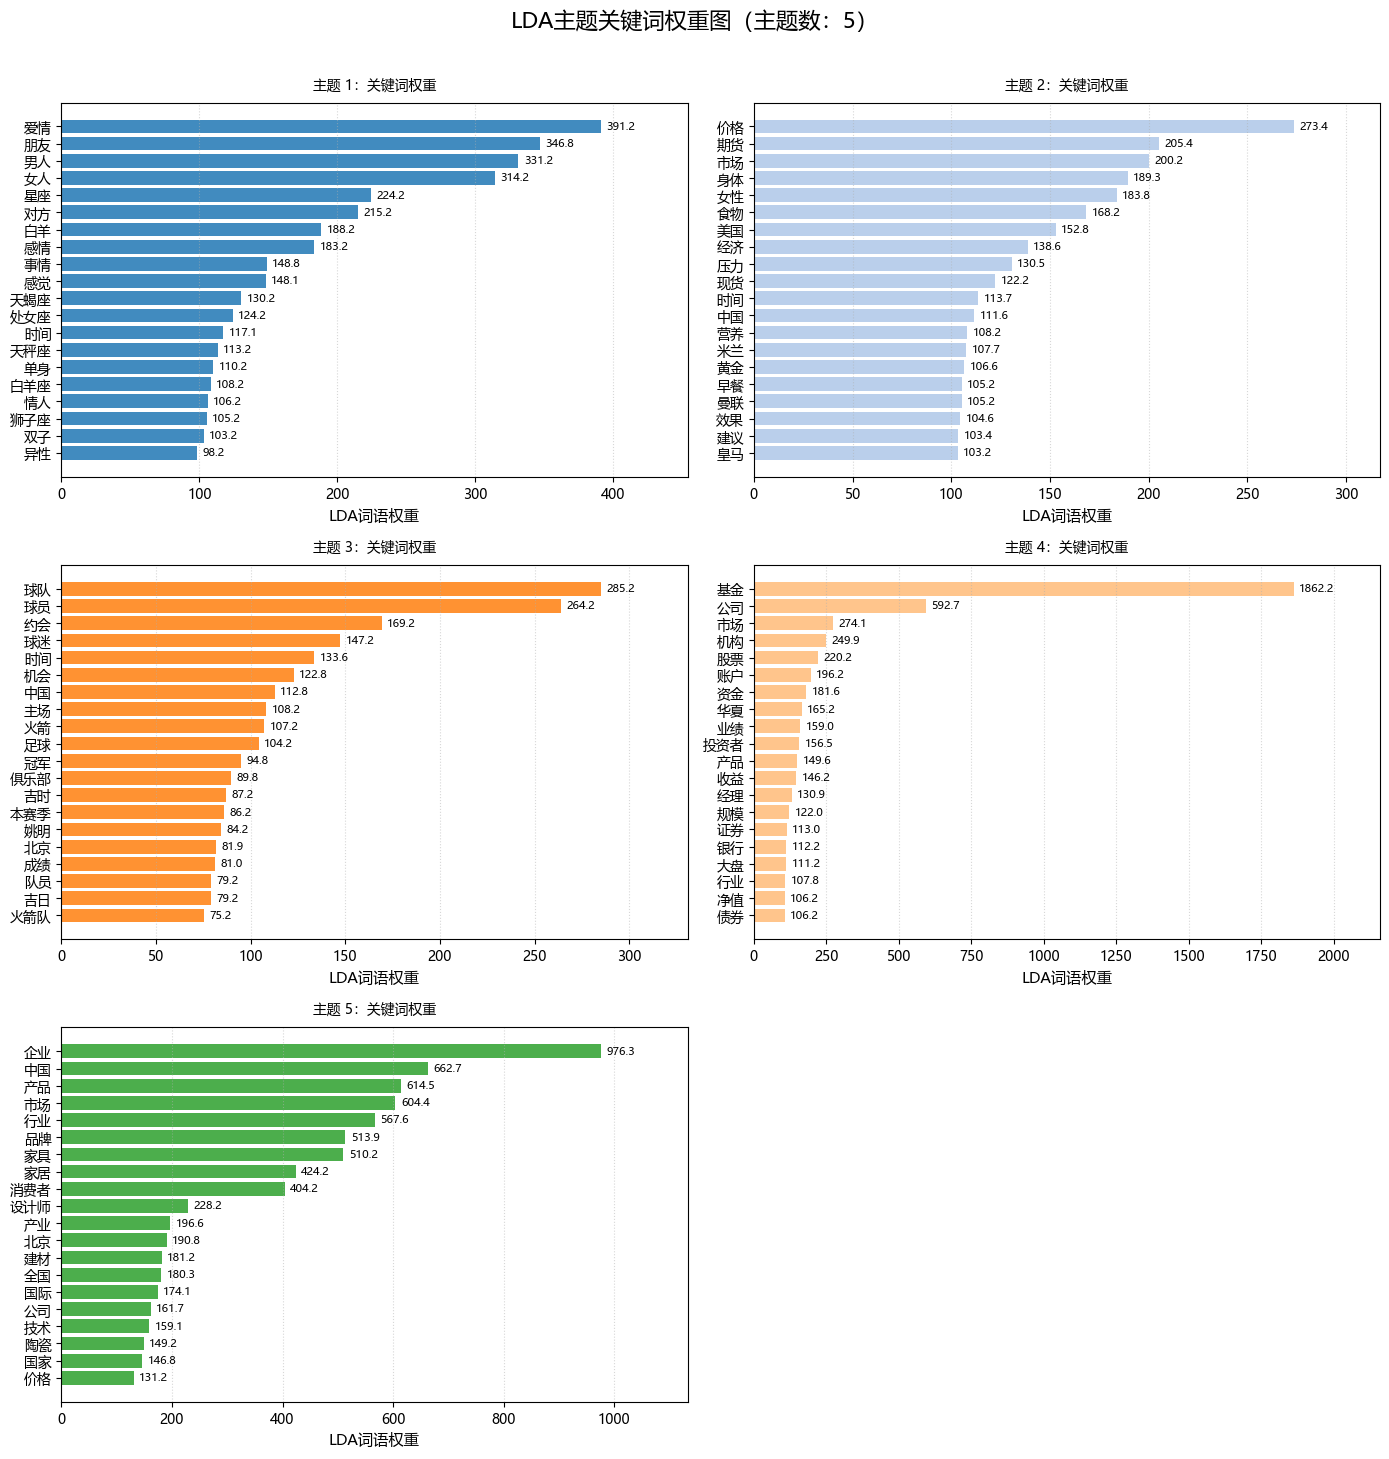

图片保存位置：
C:\temp\lda_thucnews\LDA主题关键词_K5.png


In [14]:
# -----------------------------------------------------------------------------
# Step 7：绘制LDA主题关键词权重图
# - 关键词按照权重降序排列
# - 权重最大的关键词显示在最上方
# - 每个Topic使用不同颜色
# - Topic数量自动从topic_word判断
# -----------------------------------------------------------------------------

import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager


# =============================================================================
# 1. 自动确定主题数量
# =============================================================================

# topic_word的形状为：主题数 × 词语数
N_TOPICS = topic_word.shape[0]

print("当前主题数量：", N_TOPICS)


# =============================================================================
# 2. 屏蔽中文字体警告
# =============================================================================

warnings.filterwarnings(
    "ignore",
    message=r"Glyph .* missing from current font"
)


# =============================================================================
# 3. 设置中文字体
# =============================================================================

font_candidates = [
    r"C:\Windows\Fonts\msyh.ttc",
    r"C:\Windows\Fonts\msyhbd.ttc",
    r"C:\Windows\Fonts\simhei.ttf",
    r"C:\Windows\Fonts\simsun.ttc"
]

chinese_font = None

for font_path in font_candidates:

    if os.path.exists(font_path):

        font_manager.fontManager.addfont(font_path)

        chinese_font = font_manager.FontProperties(
            fname=font_path
        )

        plt.rcParams["font.family"] = chinese_font.get_name()

        print("使用中文字体：", chinese_font.get_name())
        break

plt.rcParams["axes.unicode_minus"] = False


# =============================================================================
# 4. 根据Topic数量自动设置子图
# =============================================================================

N_COLS = 2

N_ROWS = int(
    np.ceil(N_TOPICS / N_COLS)
)

fig, axes = plt.subplots(
    nrows=N_ROWS,
    ncols=N_COLS,
    figsize=(14, 4.8 * N_ROWS)
)

axes = np.atleast_1d(axes).flatten()


# =============================================================================
# 5. 为不同Topic设置不同颜色
# =============================================================================

color_map = plt.colormaps["tab20"]

topic_colors = [
    color_map(i % color_map.N)
    for i in range(N_TOPICS)
]


# =============================================================================
# 6. 绘制各Topic关键词权重
# =============================================================================

for topic_index, word_weights in enumerate(topic_word):

    top_indices = (
        word_weights
        .argsort()[::-1][:N_TOP_WORDS]
    )

    top_words = feature_names[top_indices]
    top_weights = word_weights[top_indices]

    ax = axes[topic_index]

    ax.barh(
        y=top_words,
        width=top_weights,
        color=topic_colors[topic_index],
        alpha=0.85
    )

    # 最大权重显示在最上方
    ax.invert_yaxis()

    ax.set_title(
        f"主题 {topic_index + 1}：关键词权重",
        fontsize=13,
        fontproperties=chinese_font,
        pad=10
    )

    ax.set_xlabel(
        "LDA词语权重",
        fontsize=11,
        fontproperties=chinese_font
    )

    ax.set_ylabel("")

    for label in ax.get_yticklabels():
        label.set_fontproperties(chinese_font)
        label.set_fontsize(10)

    ax.grid(
        axis="x",
        linestyle=":",
        alpha=0.5
    )

    # 在柱形末端显示权重值
    max_weight = top_weights.max()

    for word_index, weight in enumerate(top_weights):

        ax.text(
            weight + max_weight * 0.01,
            word_index,
            f"{weight:.1f}",
            va="center",
            fontsize=8
        )

    ax.set_xlim(
        0,
        max_weight * 1.16
    )


# =============================================================================
# 7. 删除空白子图
# =============================================================================

for index in range(N_TOPICS, len(axes)):

    fig.delaxes(
        axes[index]
    )


# =============================================================================
# 8. 调整布局
# =============================================================================

fig.suptitle(
    f"LDA主题关键词权重图（主题数：{N_TOPICS}）",
    fontsize=16,
    fontproperties=chinese_font,
    y=1.01
)

plt.tight_layout()


# =============================================================================
# 9. 保存图片
# =============================================================================

# 如果前面没有定义OUTPUT_DIR，则使用默认路径
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = r"C:\temp\lda_thucnews"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

topic_plot_path = os.path.join(
    OUTPUT_DIR,
    f"LDA主题关键词_K{N_TOPICS}.png"
)

plt.savefig(
    topic_plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("图片保存位置：")
print(topic_plot_path)

### 每篇文档所属的LDA主题

,文件名,实际类别,模型主题,最高主题概率
0,224237.txt,家居,主题 5,0.953161
1,224519.txt,家居,主题 1,0.544778
2,228865.txt,家居,主题 5,0.998485
3,229138.txt,家居,主题 5,0.474706
4,229204.txt,家居,主题 5,0.992598
5,229264.txt,家居,主题 5,0.913142
6,229317.txt,家居,主题 5,0.880807
7,229373.txt,家居,主题 5,0.993332
8,229676.txt,家居,主题 5,0.895371
9,229810.txt,家居,主题 5,0.994186


### 每个实际类别中的100篇文档被分到哪些LDA主题

模型主题,主题 1,主题 2,主题 3,主题 4,主题 5,合计
实际类别,,,,,,
家居,1,0,0,0,99,100
星座,98,1,0,0,1,100
时尚,13,71,0,0,16,100
体育,0,10,90,0,0,100
财经,2,39,0,57,2,100


### LDA主题与实际类别的对应关系

,LDA主题,对应的实际类别
0,主题 1,星座
1,主题 2,时尚
2,主题 3,体育
3,主题 4,财经
4,主题 5,家居


### 实际类别与LDA模型判断类别的对比

,文件名,实际类别,模型主题,模型判断类别,最高主题概率,判断结果
0,224237.txt,家居,主题 5,家居,0.9532,一致
1,224519.txt,家居,主题 1,星座,0.5448,不一致
2,228865.txt,家居,主题 5,家居,0.9985,一致
3,229138.txt,家居,主题 5,家居,0.4747,一致
4,229204.txt,家居,主题 5,家居,0.9926,一致
5,229264.txt,家居,主题 5,家居,0.9131,一致
6,229317.txt,家居,主题 5,家居,0.8808,一致
7,229373.txt,家居,主题 5,家居,0.9933,一致
8,229676.txt,家居,主题 5,家居,0.8954,一致
9,229810.txt,家居,主题 5,家居,0.9942,一致


实际类别与模型判断类别的一致率：83.00%


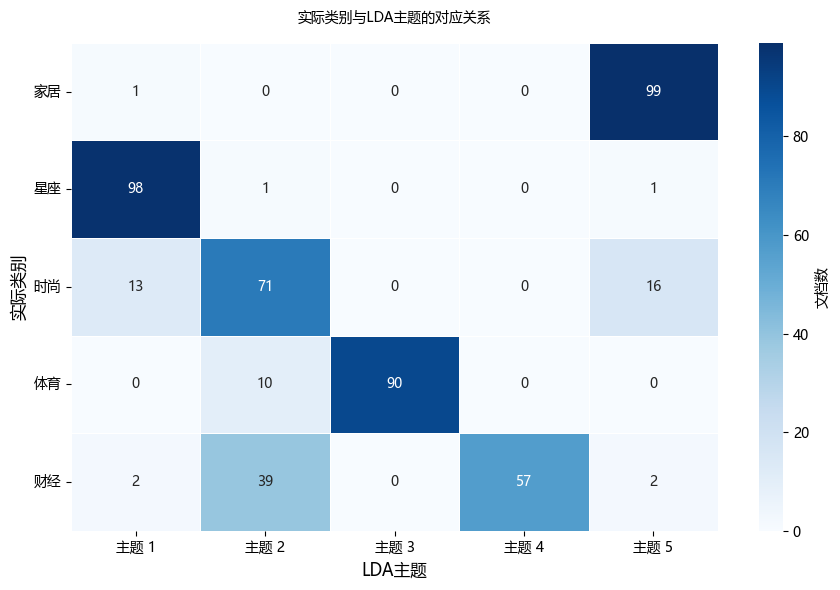

热图保存位置： C:\temp\lda_thucnews\LDA实际类别与主题热图.png

全部结果保存到：
C:\temp\lda_thucnews


In [15]:
# -----------------------------------------------------------------------------
# Step 8
# 每篇文档主题判断 + 实际类别对比 + 交叉表 + 热图
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown


# =============================================================================
# 1. 判断每篇文档属于哪个LDA主题
# =============================================================================

# 每篇文档选择概率最大的主题
predicted_topic_index = document_topic.argmax(axis=1)

df_documents["模型主题编号"] = predicted_topic_index + 1

df_documents["模型主题"] = [
    f"主题 {topic_index + 1}"
    for topic_index in predicted_topic_index
]

df_documents["最高主题概率"] = document_topic.max(axis=1)


# 添加每个主题的概率
for topic_index in range(N_TOPICS):

    df_documents[f"主题{topic_index + 1}概率"] = (
        document_topic[:, topic_index]
    )


display(Markdown("### 每篇文档所属的LDA主题"))

display(
    df_documents[
        [
            "文件名",
            "实际类别",
            "模型主题",
            "最高主题概率"
        ]
    ].head(20)
)


# =============================================================================
# 2. 建立“实际类别 × LDA主题”交叉表
# =============================================================================

topic_columns = [
    f"主题 {i + 1}"
    for i in range(N_TOPICS)
]

folder_topic_table = pd.crosstab(
    df_documents["实际类别"],
    df_documents["模型主题"]
)

folder_topic_table = folder_topic_table.reindex(
    index=CATEGORIES,
    columns=topic_columns,
    fill_value=0
)

# 增加每行合计
folder_topic_table_with_total = folder_topic_table.copy()
folder_topic_table_with_total["合计"] = (
    folder_topic_table_with_total.sum(axis=1)
)

display(
    Markdown(
        "### 每个实际类别中的100篇文档被分到哪些LDA主题"
    )
)

display(folder_topic_table_with_total)


# =============================================================================
# 3. 自动建立“LDA主题—实际类别”对应关系
#
# 每个主题中数量最多的实际类别，
# 被视为该主题对应的类别名称。
# =============================================================================

topic_to_category = {}

for topic_name in topic_columns:

    category_counts = (
        df_documents.loc[
            df_documents["模型主题"] == topic_name,
            "实际类别"
        ]
        .value_counts()
    )

    if len(category_counts) > 0:
        topic_to_category[topic_name] = category_counts.index[0]
    else:
        topic_to_category[topic_name] = "未分类"


df_topic_mapping = pd.DataFrame({
    "LDA主题": list(topic_to_category.keys()),
    "对应的实际类别": list(topic_to_category.values())
})

display(Markdown("### LDA主题与实际类别的对应关系"))
display(df_topic_mapping)


# =============================================================================
# 4. 实际类别与模型判断类别的对比
# =============================================================================

df_documents["模型判断类别"] = (
    df_documents["模型主题"]
    .map(topic_to_category)
)

df_documents["判断结果"] = np.where(
    df_documents["实际类别"]
    == df_documents["模型判断类别"],
    "一致",
    "不一致"
)

comparison_columns = [
    "文件名",
    "实际类别",
    "模型主题",
    "模型判断类别",
    "最高主题概率",
    "判断结果"
]

df_comparison = df_documents[comparison_columns].copy()

display(Markdown("### 实际类别与LDA模型判断类别的对比"))

display(
    df_comparison
    .head(30)
    .style.format({
        "最高主题概率": "{:.4f}"
    })
)


# =============================================================================
# 5. 计算一致率
# =============================================================================

accuracy = (
    df_documents["实际类别"]
    == df_documents["模型判断类别"]
).mean()

print(f"实际类别与模型判断类别的一致率：{accuracy:.2%}")


# =============================================================================
# 6. 绘制“实际类别 × LDA主题”热图
# =============================================================================

plt.figure(figsize=(9, 6))

ax = sns.heatmap(
    folder_topic_table,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "文档数"
    }
)

ax.set_title(
    "实际类别与LDA主题的对应关系",
    fontsize=15,
    pad=15,
    fontproperties=chinese_font
)

ax.set_xlabel(
    "LDA主题",
    fontsize=12,
    fontproperties=chinese_font
)

ax.set_ylabel(
    "实际类别",
    fontsize=12,
    fontproperties=chinese_font
)


# 设置坐标轴中文字体
for label in ax.get_xticklabels():
    label.set_fontproperties(chinese_font)
    label.set_rotation(0)

for label in ax.get_yticklabels():
    label.set_fontproperties(chinese_font)
    label.set_rotation(0)


# 设置热图数字字体
for text in ax.texts:
    text.set_fontproperties(chinese_font)


# 设置颜色条字体
colorbar = ax.collections[0].colorbar

if colorbar is not None:

    colorbar.ax.yaxis.label.set_fontproperties(
        chinese_font
    )

    for label in colorbar.ax.get_yticklabels():
        label.set_fontproperties(chinese_font)


plt.tight_layout()


# =============================================================================
# 7. 保存热图
# =============================================================================

heatmap_path = os.path.join(
    OUTPUT_DIR,
    "LDA实际类别与主题热图.png"
)

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("热图保存位置：", heatmap_path)


# =============================================================================
# 8. 保存分析结果
# =============================================================================

df_topics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "01_LDA主题关键词.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

folder_topic_table_with_total.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_实际类别与LDA主题交叉表.csv"
    ),
    encoding="utf-8-sig"
)

df_topic_mapping.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "03_LDA主题与实际类别对应表.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

df_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "04_文档LDA主题判断结果.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

print("\n全部结果保存到：")
print(OUTPUT_DIR)

In [16]:
#%pip install pyLDAvis

In [17]:
lda
X_tf
vectorizer

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function nou...001899F596CA0>
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",None
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [18]:
# =============================================================================
# Step 9：pyLDAvisによるLDAトピック可視化
# =============================================================================

import pyLDAvis
import pyLDAvis.lda_model
from pathlib import Path
import webbrowser


# -----------------------------------------------------------------------------
# 1. pyLDAvisデータを作成
# -----------------------------------------------------------------------------

print("pyLDAvisを作成しています……")

lda_vis = pyLDAvis.lda_model.prepare(
    lda,              # 学習済みscikit-learn LDAモデル
    X_tf,             # 文書 × 単語のCount行列
    vectorizer,       # CountVectorizer
    mds="pcoa",       # トピック間距離を2次元に配置
    sort_topics=False
)


# -----------------------------------------------------------------------------
# 2. HTMLファイルとして保存
# -----------------------------------------------------------------------------

# 保存先は1か所だけ
output_html = Path("lda_pyldavis.html").resolve()

pyLDAvis.save_html(
    lda_vis,
    str(output_html)
)

print(f"HTMLを保存しました：{output_html}")


# -----------------------------------------------------------------------------
# 3. 保存したHTMLをブラウザーで自動表示
# -----------------------------------------------------------------------------

webbrowser.open(output_html.as_uri())

print("ブラウザーでpyLDAvisを開きました。")

pyLDAvisを作成しています……
HTMLを保存しました：C:\Users\mzjin\lda_pyldavis.html
ブラウザーでpyLDAvisを開きました。
